In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
image = cv2.imread("my_image.jpeg")

if image is None:
    print("Error: Image could not be loaded.")
else:
    print("Image loaded successfully!")
    print("Image shape:", image.shape)

Image loaded successfully!
Image shape: (1537, 1023, 3)


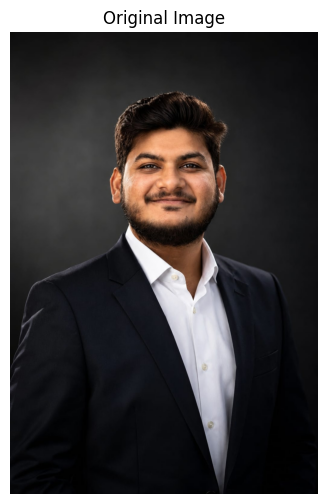

In [3]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

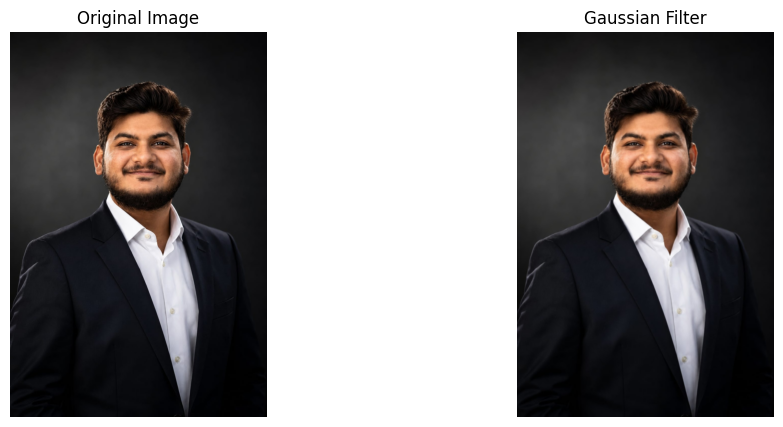

In [4]:
gaussian_image = cv2.GaussianBlur(image, (5, 5), 0)
gaussian_rgb = cv2.cvtColor(gaussian_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gaussian_rgb)
plt.title("Gaussian Filter")
plt.axis("off")

plt.show()

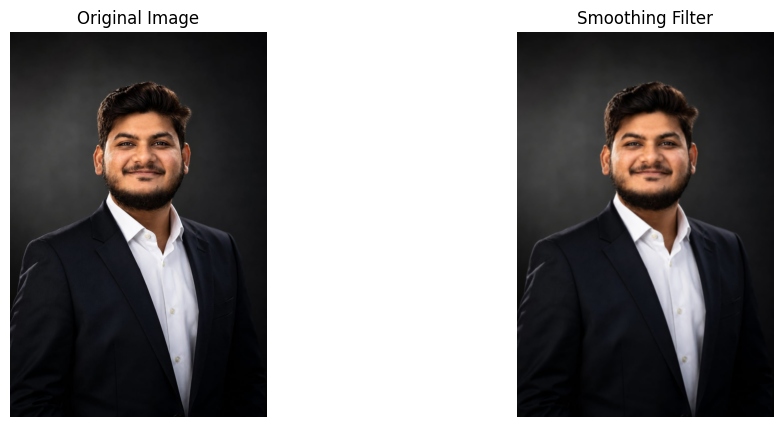

In [5]:
smoothing_image = cv2.GaussianBlur(image, (7, 7), 0)
smoothing_rgb = cv2.cvtColor(smoothing_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(smoothing_rgb)
plt.title("Smoothing Filter")
plt.axis("off")

plt.show()

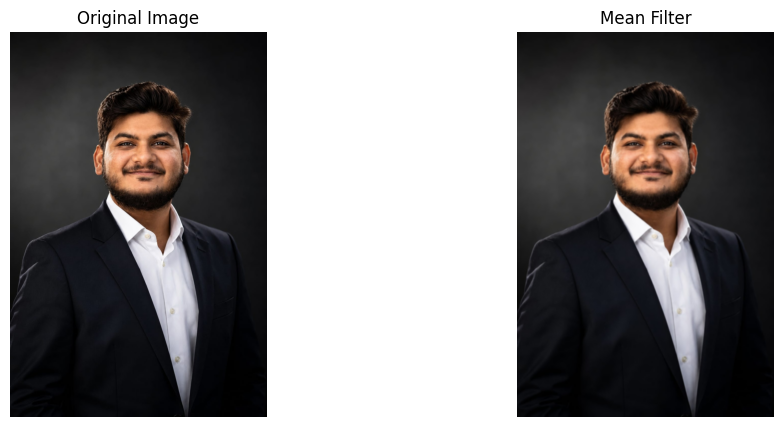

In [6]:
mean_image = cv2.blur(image, (5, 5))
mean_rgb = cv2.cvtColor(mean_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mean_rgb)
plt.title("Mean Filter")
plt.axis("off")

plt.show()

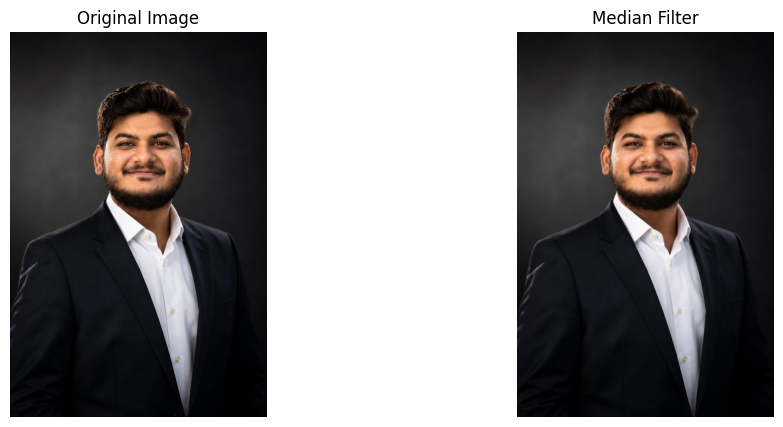

In [7]:
median_image = cv2.medianBlur(image, 5)
median_rgb = cv2.cvtColor(median_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(median_rgb)
plt.title("Median Filter")
plt.axis("off")

plt.show()


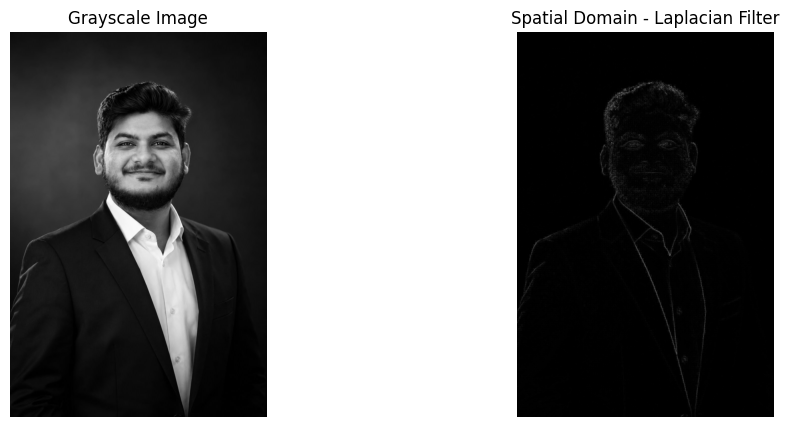

In [8]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

laplacian = cv2.Laplacian(gray_image, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(laplacian, cmap="gray")
plt.title("Spatial Domain - Laplacian Filter")
plt.axis("off")

plt.show()

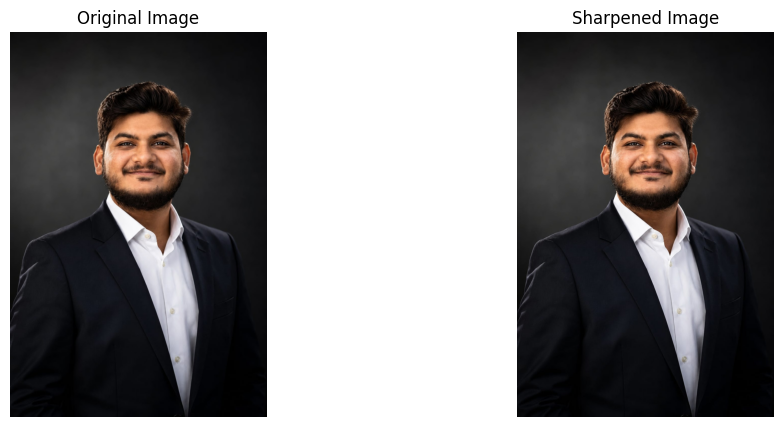

In [9]:
blurred = cv2.GaussianBlur(image, (5, 5), 0)

sharpened = cv2.addWeighted(
    image, 1.5,
    blurred, -0.5,
    0
)

sharpened_rgb = cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sharpened_rgb)
plt.title("Sharpened Image")
plt.axis("off")

plt.show()

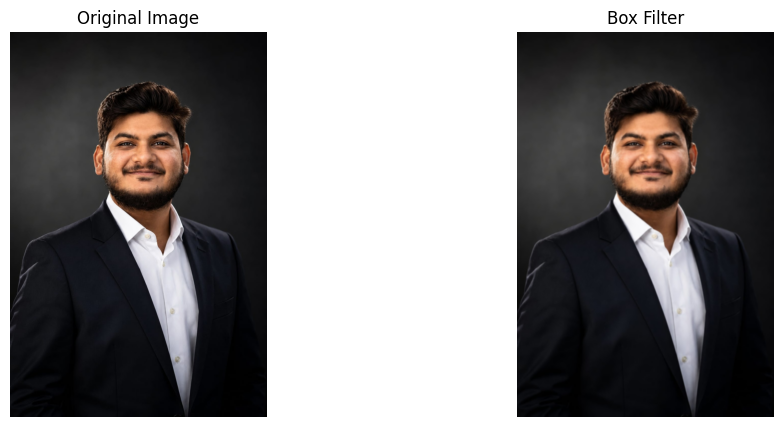

In [10]:
box_image = cv2.boxFilter(image, -1, (5, 5))
box_rgb = cv2.cvtColor(box_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(box_rgb)
plt.title("Box Filter")
plt.axis("off")

plt.show()

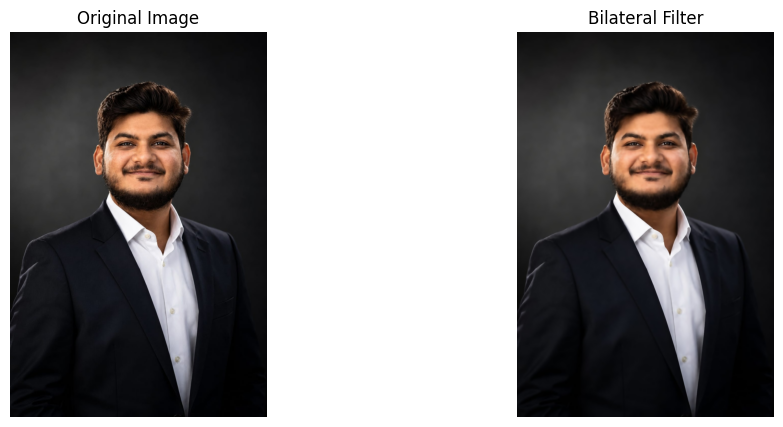

In [11]:
bilateral_image = cv2.bilateralFilter(image, 9, 75, 75)
bilateral_rgb = cv2.cvtColor(bilateral_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(bilateral_rgb)
plt.title("Bilateral Filter")
plt.axis("off")

plt.show()

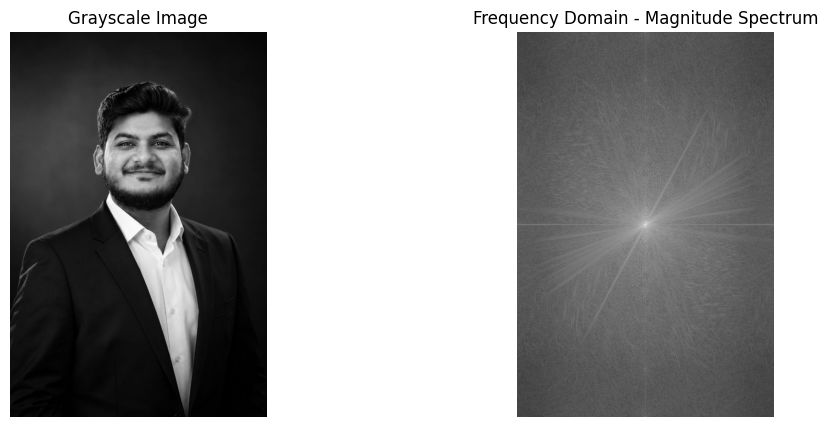

In [12]:
dft = np.fft.fft2(gray_image)
dft_shift = np.fft.fftshift(dft)

magnitude_spectrum = 20 * np.log(np.abs(dft_shift) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(magnitude_spectrum, cmap="gray")
plt.title("Frequency Domain - Magnitude Spectrum")
plt.axis("off")

plt.show()

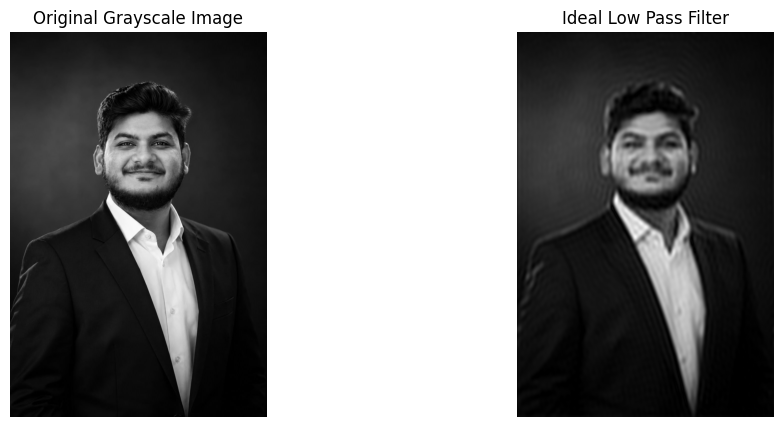

In [13]:
rows, cols = gray_image.shape
crow, ccol = rows // 2, cols // 2

radius = 50

ideal_mask = np.zeros((rows, cols), np.uint8)
cv2.circle(ideal_mask, (ccol, crow), radius, 1, -1)

ideal_filtered = dft_shift * ideal_mask
ideal_ishift = np.fft.ifftshift(ideal_filtered)

ideal_image = np.fft.ifft2(ideal_ishift)
ideal_image = np.abs(ideal_image)

ideal_image = cv2.normalize(
    ideal_image, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(ideal_image, cmap="gray")
plt.title("Ideal Low Pass Filter")
plt.axis("off")

plt.show()

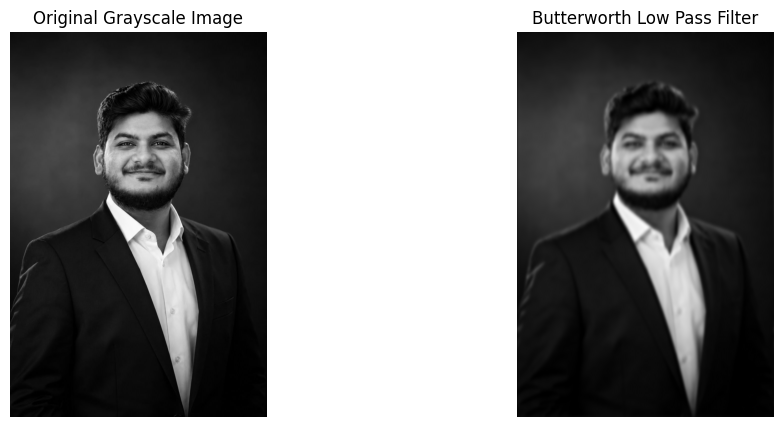

In [14]:
D0 = 50
n = 2

u = np.arange(cols)
v = np.arange(rows)
U, V = np.meshgrid(u, v)

D = np.sqrt((U - ccol) ** 2 + (V - crow) ** 2)

butterworth_mask = 1 / (1 + (D / D0) ** (2 * n))

butterworth_filtered = dft_shift * butterworth_mask
butterworth_ishift = np.fft.ifftshift(butterworth_filtered)

butterworth_image = np.fft.ifft2(butterworth_ishift)
butterworth_image = np.abs(butterworth_image)

butterworth_image = cv2.normalize(
    butterworth_image, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(butterworth_image, cmap="gray")
plt.title("Butterworth Low Pass Filter")
plt.axis("off")

plt.show()

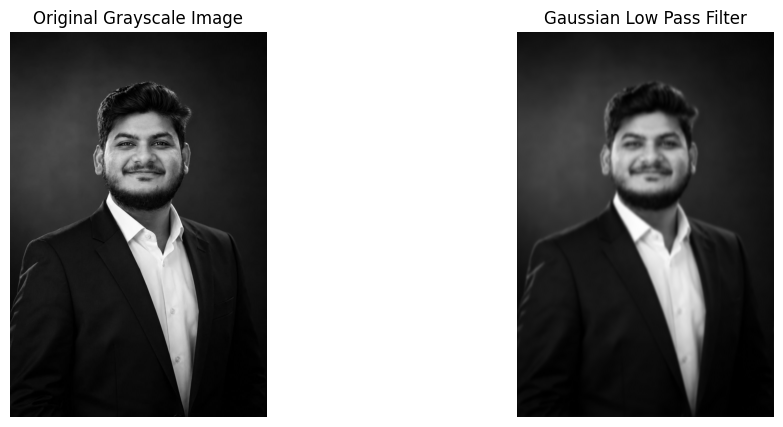

In [15]:
D0 = 50

gaussian_mask = np.exp(-(D ** 2) / (2 * (D0 ** 2)))

gaussian_filtered = dft_shift * gaussian_mask
gaussian_ishift = np.fft.ifftshift(gaussian_filtered)

gaussian_image = np.fft.ifft2(gaussian_ishift)
gaussian_image = np.abs(gaussian_image)

gaussian_image = cv2.normalize(
    gaussian_image, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gaussian_image, cmap="gray")
plt.title("Gaussian Low Pass Filter")
plt.axis("off")

plt.show()

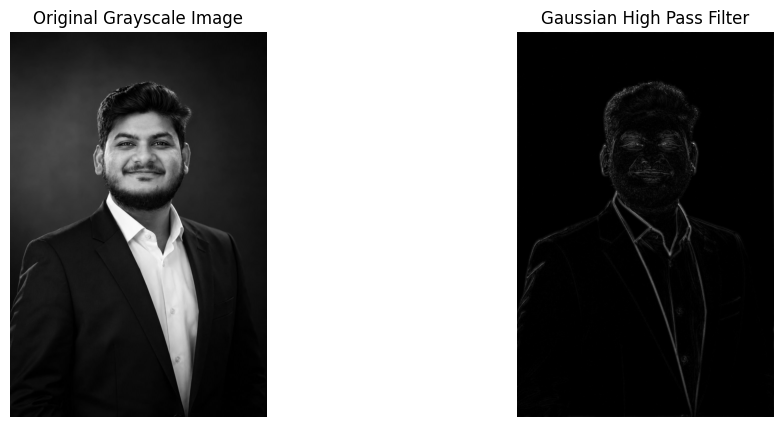

In [16]:
gaussian_high_pass = 1 - gaussian_mask

high_pass_filtered = dft_shift * gaussian_high_pass
high_pass_ishift = np.fft.ifftshift(high_pass_filtered)

high_pass_image = np.fft.ifft2(high_pass_ishift)
high_pass_image = np.abs(high_pass_image)

high_pass_image = cv2.normalize(
    high_pass_image, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(high_pass_image, cmap="gray")
plt.title("Gaussian High Pass Filter")
plt.axis("off")

plt.show()

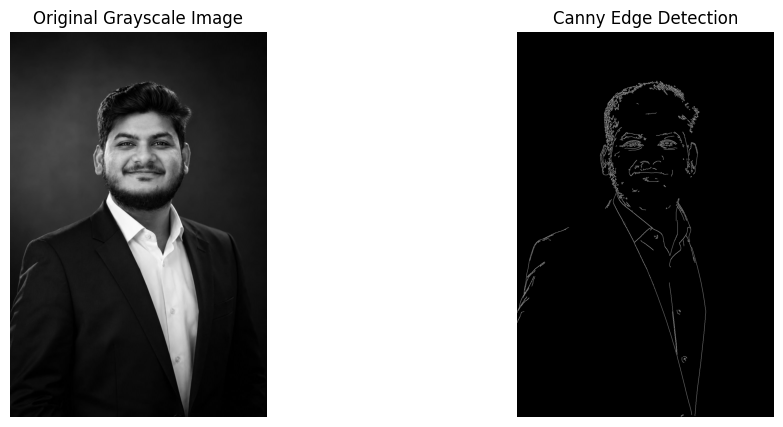

In [17]:
edges = cv2.Canny(gray_image, 100, 200)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

plt.show()

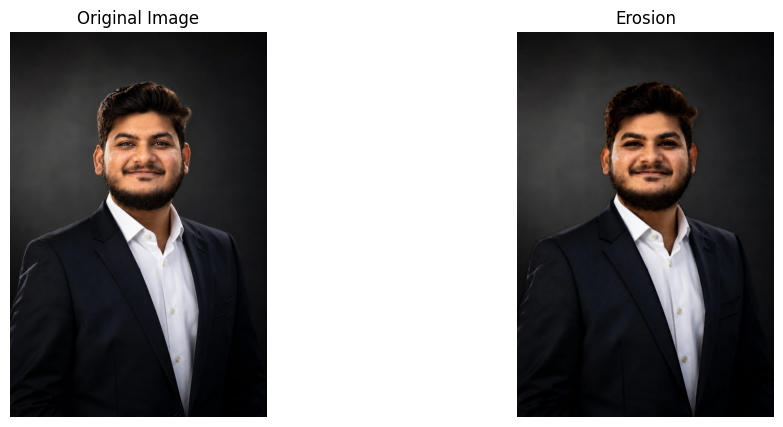

In [18]:
kernel = np.ones((5, 5), np.uint8)

erosion = cv2.erode(image, kernel, iterations=1)
erosion_rgb = cv2.cvtColor(erosion, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(erosion_rgb)
plt.title("Erosion")
plt.axis("off")

plt.show()

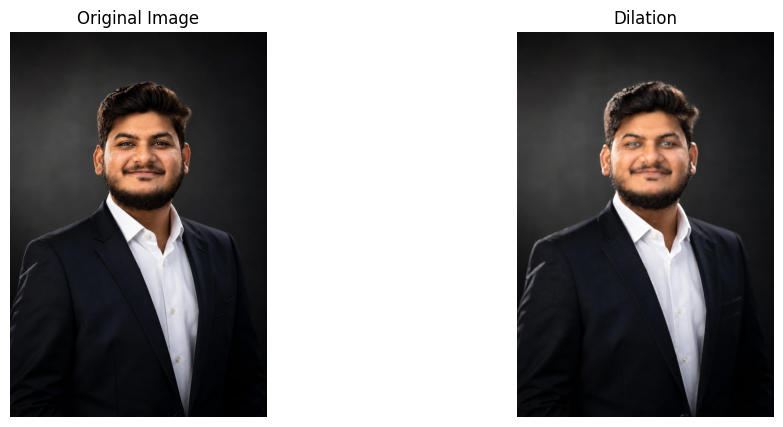

In [19]:
kernel = np.ones((5, 5), np.uint8)

dilation = cv2.dilate(image, kernel, iterations=1)
dilation_rgb = cv2.cvtColor(dilation, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(dilation_rgb)
plt.title("Dilation")
plt.axis("off")

plt.show()

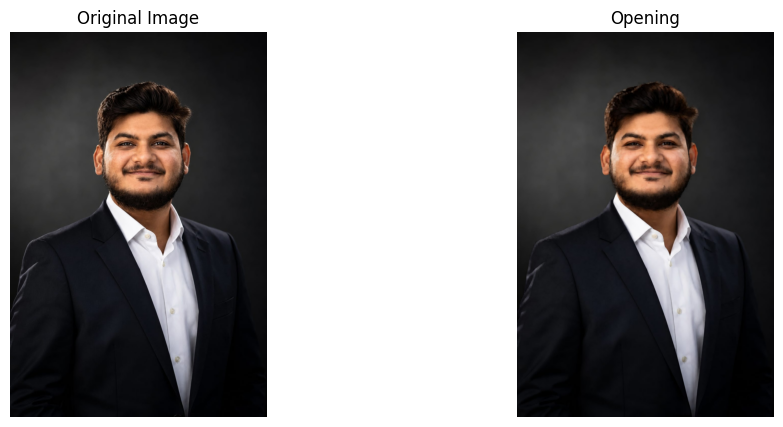

In [20]:
kernel = np.ones((5, 5), np.uint8)

opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
opening_rgb = cv2.cvtColor(opening, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(opening_rgb)
plt.title("Opening")
plt.axis("off")

plt.show()

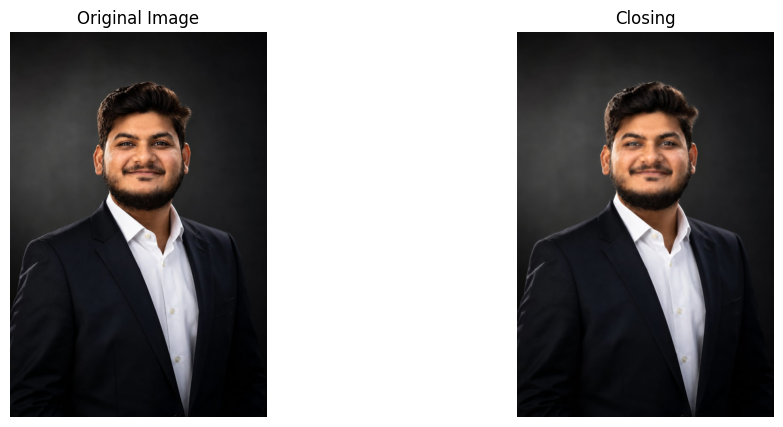

In [21]:
kernel = np.ones((5, 5), np.uint8)

closing = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)
closing_rgb = cv2.cvtColor(closing, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(closing_rgb)
plt.title("Closing")
plt.axis("off")

plt.show()

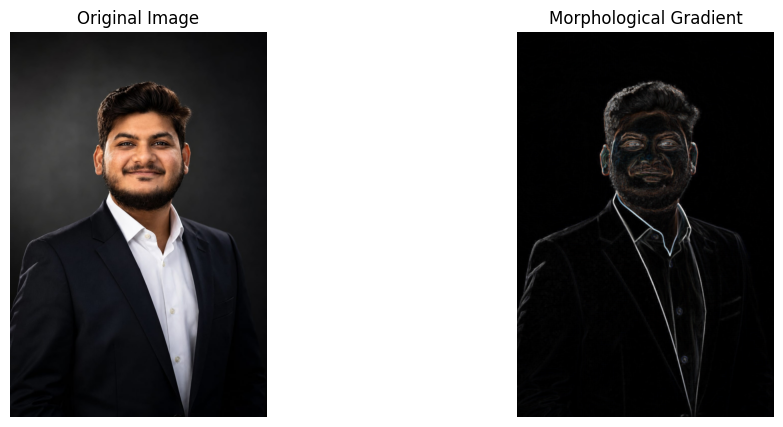

In [22]:
kernel = np.ones((5, 5), np.uint8)

gradient = cv2.morphologyEx(image, cv2.MORPH_GRADIENT, kernel)
gradient_rgb = cv2.cvtColor(gradient, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gradient_rgb)
plt.title("Morphological Gradient")
plt.axis("off")

plt.show()